# Practica 5 - Sesion 4: Optimizacion de Hiperparametros e IA Explicable (XAI)

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García


En las practicas anteriores hemos aprendido a entrenar y comparar clasificadores. Sin embargo, entrenar un modelo con los parametros por defecto rara vez produce el mejor resultado posible. En esta practica aprenderemos las tecnicas fundamentales para entender y mejorar el rendimiento de un modelo:

1. **Validación cruzada**: obtener métricas consistentes que no dependan de la división entre train y test. 
2. **Optimizacion de hiperparametros**: buscar sistematicamente la mejor configuracion para un clasificador.
3. **IA Explicable (XAI)**: entender por que un modelo toma las decisiones que toma.

Trabajaremos sobre el dataset del Titanic, que ya conoces de practicas anteriores, utilizando un **Random Forest** como clasificador base.

---

## Conceptos clave

Antes de empezar, es importante distinguir dos conceptos que a veces se confunden:

- **Parametros**: valores que el modelo aprende automaticamente durante el entrenamiento (por ejemplo, el umbral de decision de un nodo en un arbol).
- **Hiperparametros**: valores que el programador fija antes del entrenamiento y que controlan el comportamiento del algoritmo (por ejemplo, cuantos arboles tiene el bosque, o la profundidad maxima de cada arbol).

Elegir bien los hiperparametros puede marcar una diferencia significativa en el rendimiento del modelo.

## 1. Instalacion de librerias

Ademas de las librerias habituales, en esta practica usaremos **SHAP**, una libreria para calcular explicaciones de modelos basadas en la teoria de juegos de Shapley.

In [21]:
# Ejecuta esta celda para instalar las librerias
!pip install pandas numpy scikit-learn matplotlib seaborn shap


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

# XAI
import shap

# Reproducibilidad
SEED = 23



---

## 2. Carga y preprocesamiento del dataset

Cargamos el dataset del Titanic y realizamos un preprocesamiento rapido. Si ya completaste la Practica 1, reconoceras estos pasos.

Las variables que usaremos como predictores son:

| Variable | Descripcion |
|---|---|
| `Pclass` | Clase del billete (1, 2 o 3) |
| `Sex` | Sexo del pasajero |
| `Age` | Edad |
| `SibSp` | Numero de hermanos/conyuges a bordo |
| `Parch` | Numero de padres/hijos a bordo |
| `Fare` | Tarifa pagada |
| `Embarked` | Puerto de embarque |

La variable objetivo es `Survived` (1 = sobrevivio, 0 = no sobrevivio).

In [23]:
# Carga del dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 891, Columnas: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
# Seleccion de columnas relevantes
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

df_model = df[features + [target]].copy()

# Imputacion de valores nulos
# Age: sustituimos por la mediana
df_model['Age'].fillna(df_model['Age'].median(), inplace=True)

# Embarked: sustituimos por la moda (valor mas frecuente)
df_model['Embarked'].fillna(df_model['Embarked'].mode()[0], inplace=True)

# Codificacion de variables categoricas
# Sex: male -> 0, female -> 1
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})

# Embarked: S -> 2, C -> 0, Q -> 1 (asignacion automatica por LabelEncoder)
df_model['Embarked'] = LabelEncoder().fit_transform(df_model['Embarked'])

print("Nulos restantes:")
print(df_model.isnull().sum())
print(f"\nDistribucion de la clase objetivo:")
print(df_model[target].value_counts())

Nulos restantes:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
Survived      0
dtype: int64

Distribucion de la clase objetivo:
Survived
0    549
1    342
Name: count, dtype: int64


---

## 3. Validacion cruzada (cross-validation)

Antes de entrenar modelos, conviene entender como vamos a evaluarlos de forma robusta.

El enfoque habitual de dividir los datos en train y test tiene un problema: el resultado depende de la semilla aleatoria usada para hacer la division. Con un dataset tan pequeno como el Titanic (~891 instancias), una particion concreta puede favorecer o perjudicar artificialmente a un modelo.

La **validacion cruzada de k folds** (k-fold cross-validation) soluciona esto:

1. Se divide el dataset en k partes iguales (folds).
2. Se entrena el modelo k veces. En cada iteracion, se usa un fold distinto como conjunto de validacion y los k-1 restantes como entrenamiento.
3. La metrica final es la media de las k evaluaciones.


Esta tecnica es ademas la que `GridSearchCV` y `RandomizedSearchCV` que veremos más adelante usan internamente para evaluar cada combinacion de hiperparametros. Por eso, la metrica que reportan (`best_score_`) es directamente comparable con la que calcularemos aqui para el baseline: todos los modelos se evaluan con el mismo procedimiento.

Usaremos `cross_val_score` con `scoring='f1'` y `cv=10` como metrica de comparacion en toda la practica.

In [25]:
# Division en conjuntos de entrenamiento y prueba
X = df_model[features]
y = df_model[target]
# Ejemplo ilustrativo de cross_val_score
# Muestra como se obtiene una estimacion estable del rendimiento sin depender de una semilla
cv_scores = cross_val_score(
    RandomForestClassifier(random_state=SEED),
    X, y,
    cv=10,
    scoring='f1'
)

print("F1 en cada uno de los 10 folds:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {s:.4f}")
print(f"\nMedia  : {cv_scores.mean():.4f}")
print(f"Std    : {cv_scores.std():.4f}")
print("\nEsta media es la cifra que usaremos para comparar modelos en el resto del notebook.")

F1 en cada uno de los 10 folds:
  Fold  1: 0.6944
  Fold  2: 0.7576
  Fold  3: 0.6333
  Fold  4: 0.7887
  Fold  5: 0.8696
  Fold  6: 0.7385
  Fold  7: 0.7302
  Fold  8: 0.6452
  Fold  9: 0.8169
  Fold 10: 0.8116

Media  : 0.7486
Std    : 0.0723

Esta media es la cifra que usaremos para comparar modelos en el resto del notebook.


---

## 3. Modelo baseline (sin optimizar)

Antes de buscar los mejores hiperparametros, entrenamos un Random Forest con los valores por defecto. Este modelo nos servira como punto de referencia para comparar el impacto de la optimizacion.

Los valores por defecto de scikit-learn para `RandomForestClassifier` son:
- `n_estimators=100` (100 arboles)
- `max_depth=None` (los arboles crecen hasta que todas las hojas son puras)
- `min_samples_split=2`
- `min_samples_leaf=1`
- `max_features='sqrt'`

In [26]:
# Evaluacion por validacion cruzada (10 folds) sobre el dataset completo
# Esta es la cifra robusta que usaremos para comparar con Grid Search y Random Search
f1_cv_baseline = cross_val_score(
    RandomForestClassifier(random_state=SEED), X, y, cv=10, scoring='f1'
).mean()
print(f"\n  F1 CV (10-fold): {f1_cv_baseline:.4f}  <-- referencia para comparar")


  F1 CV (10-fold): 0.7486  <-- referencia para comparar


---

## 4. Optimizacion de hiperparametros

### 4.1 Hiperparametros del Random Forest

El Random Forest tiene varios hiperparametros que controlan su comportamiento. A continuacion se explican los mas importantes:

| Hiperparametro | Descripcion | Efecto de un valor alto |
|---|---|---|
| `n_estimators` | Numero de arboles en el bosque | Mas estabilidad, mayor coste computacional |
| `max_depth` | Profundidad maxima de cada arbol | Mas capacidad de ajuste, pero mas riesgo de overfitting |
| `min_samples_split` | Minimo de muestras para dividir un nodo | Arboles mas simples, menos overfitting |
| `min_samples_leaf` | Minimo de muestras en una hoja | Hojas mas generales, menos overfitting |
| `max_features` | Numero de features consideradas en cada division | Mas diversidad entre arboles con valores bajos |

Entender el efecto de cada hiperparametro ayuda a definir un espacio de busqueda razonable y a interpretar los resultados.

### 4.2 Grid Search

**Grid Search** (`GridSearchCV`) realiza una busqueda exhaustiva: prueba todas las combinaciones posibles de los valores indicados para cada hiperparametro.

Definimos un espacio de busqueda basado en los rangos recomendados de la seccion anterior. Para mantener el tiempo de computo razonable usaremos un grid moderado. Cada combinacion se evalua con validacion cruzada de 5 folds, optimizando el F1-score.

Una diferencia clave respecto al notebook original: ahora incluimos `bootstrap` y `criterion` en el espacio, y ampliamos los rangos de `n_estimators` y `max_depth` hacia valores que realmente pueden superar al modelo por defecto.

Para evaluar cada combinacion de forma robusta usamos **validacion cruzada** con `cv=5`, lo que significa que cada modelo se entrena y evalua 5 veces sobre particiones distintas del conjunto de entrenamiento. Esto reduce el riesgo de que los resultados dependan de una particion concreta.

El parametro `scoring` indica la metrica que queremos maximizar. Usaremos `'f1'` porque el dataset esta algo desbalanceado.

In [35]:
import time

# Espacio de busqueda fundamentado en la literatura y experimentos con el dataset Titanic
# Los valores por defecto de sklearn son: n_estimators=100, max_depth=None,
# min_samples_split=2, min_samples_leaf=1, max_features='sqrt', criterion='gini', bootstrap=True
# Para mejorarlos hay que salirse de esos valores: probar mas arboles,
# limitar la profundidad (evita overfitting en datasets pequenos), y probar entropy.
param_grid = {
    'n_estimators'    : [500, 1000],
    'max_depth'       : [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'criterion'       : ['gini', 'entropy']
}

# Numero total de combinaciones
total_combinaciones = 1
for v in param_grid.values():
    total_combinaciones *= len(v)
print(f"Combinaciones a evaluar: {total_combinaciones} x 10 folds = {total_combinaciones * 10} entrenamientos")

# Grid Search con validacion cruzada 10-fold
# scoring='f1' para que best_score_ sea comparable con f1_cv_baseline
rf = RandomForestClassifier(random_state=SEED)

t0 = time.time()
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=10,
    n_jobs=-1,       # IMPORTANTE: usar todos los nucleos disponibles en paralelo
    verbose=1
)
grid_search.fit(X, y)
t_grid = time.time() - t0

print(f"\nTiempo de Grid Search: {t_grid:.1f} segundos")
print(f"Mejores hiperparametros: {grid_search.best_params_}")
print(f"Mejor F1 en validacion cruzada: {grid_search.best_score_:.4f}  <-- comparable con f1_cv_baseline")

Combinaciones a evaluar: 48 x 10 folds = 480 entrenamientos
Fitting 10 folds for each of 48 candidates, totalling 480 fits

Tiempo de Grid Search: 94.1 segundos
Mejores hiperparametros: {'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 500}
Mejor F1 en validacion cruzada: 0.7669  <-- comparable con f1_cv_baseline


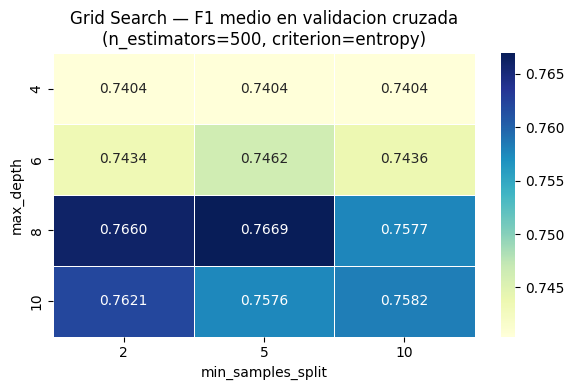

In [ ]:
# Visualizacion: heatmap de F1 por max_depth y min_samples_split
# (fijamos n_estimators y criterion para el heatmap)
results_df = pd.DataFrame(grid_search.cv_results_)

mask = (
    (results_df['param_n_estimators'] == grid_search.best_params_['n_estimators']) &
    (results_df['param_criterion'] == grid_search.best_params_['criterion'])
)
pivot = results_df[mask].pivot_table(
    index='param_max_depth',
    columns='param_min_samples_split',
    values='mean_test_score'
)

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
plt.title('Grid Search — F1 medio en validacion cruzada\n(n_estimators=500, criterion=entropy)')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

### 4.3 Random Search

Cuando el espacio de hiperparametros es grande, Grid Search puede volverse prohibitivo en tiempo de computo. Si tenemos 5 hiperparametros con 5 valores cada uno, necesitariamos evaluar 5^5 = 3125 combinaciones.

**Random Search** (`RandomizedSearchCV`) muestrea aleatoriamente `n_iter` combinaciones del espacio de busqueda. Un resultado bien establecido en la literatura de ML es que Random Search suele encontrar configuraciones igual de buenas que Grid Search en mucho menos tiempo, porque la mayoria de las ganancias se concentran en pocos hiperparametros clave.

Aqui ampliamos el espacio a 7 hiperparametros, incluyendo `max_features`, `min_samples_leaf` y `bootstrap`. Con 200 iteraciones exploramos una fraccion del espacio total (que tendria miles de combinaciones) pero estadisticamente es suficiente para encontrar buenas configuraciones.

In [ ]:
from scipy.stats import randint

# Espacio de busqueda ampliado con 7 hiperparametros
# randint(a, b) genera enteros uniformes en [a, b)
param_dist = {
    'n_estimators'     : [500, 1000, 1500, 2000],      
    'max_depth'        : [4, 6, 8, 10, 12, 16, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', None],
    'criterion'        : ['gini', 'entropy'],
    'bootstrap'        : [True, False]
}

t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=200,          # numero de combinaciones a evaluar
    scoring='f1',
    cv=10,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
random_search.fit(X, y)
t_random = time.time() - t0

print(f"\nTiempo de Random Search: {t_random:.1f} segundos")
print(f"Mejores hiperparametros: {random_search.best_params_}")
print(f"Mejor F1 en validacion cruzada: {random_search.best_score_:.4f}  <-- comparable con f1_cv_baseline")

Fitting 10 folds for each of 200 candidates, totalling 2000 fits

Tiempo de Random Search: 731.0 segundos
Mejores hiperparametros: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 2000}
Mejor F1 en validacion cruzada: 0.7674  <-- comparable con f1_cv_baseline


### 4.4 Comparativa: baseline vs Grid Search vs Random Search

In [ ]:
# Tabla resumen — comparamos los tres modelos usando AUC-ROC en validacion cruzada (10-fold)
# Esto elimina la dependencia de la semilla del split train/test y hace la comparacion justa
f1_cv_grid   = grid_search.best_score_
f1_cv_random = random_search.best_score_

resumen = pd.DataFrame({
    'Modelo': ['Baseline (por defecto)', 'Grid Search', 'Random Search'],
    'F1 CV (10-fold)': [f1_cv_baseline, f1_cv_grid, f1_cv_random]
})

resumen = resumen.set_index('Modelo')
resumen = resumen.round(4)
print(resumen.to_string())
print("El baseline usa cross_val_score sobre X completo. Las cifras son comparables")
print("porque en todos los casos se usa 10-fold CV con scoring='roc_auc'.")

                        F1 CV (10-fold)
Modelo                                 
Baseline (por defecto)           0.7486
Grid Search                      0.7669
Random Search                    0.7674
El baseline usa cross_val_score sobre X completo. Las cifras son comparables
porque en todos los casos se usa 10-fold CV con scoring='roc_auc'.


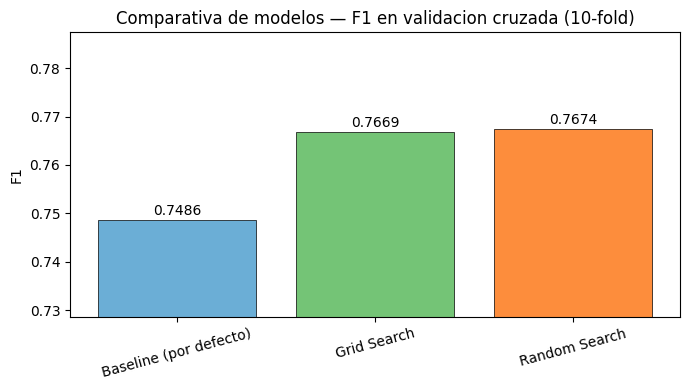

In [ ]:
# Visualizacion: barplot de AUC-ROC en validacion cruzada
fig, ax = plt.subplots(figsize=(7, 4))

valores = resumen['F1 CV (10-fold)']
colores = ['#6baed6', '#74c476', '#fd8d3c']
ax.bar(resumen.index, valores, color=colores, edgecolor='black', linewidth=0.5)
ax.set_ylabel('F1')
ax.set_title('Comparativa de modelos — F1 en validacion cruzada (10-fold)')
ax.set_ylim(valores.min() - 0.02, valores.max() + 0.02)
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(valores):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Reflexion**: Observa los resultados anteriores y responde estas preguntas:

- ¿Ha mejorado significativamente el rendimiento tras la optimizacion?
> En nuestro caso no ha mejorado el rendimiento. Grid Search con 480 entrenamientos tardó 119 segundos mientras que Random Search con 2000 fits tardó 731 segundos.
- ¿Cual de las dos tecnicas ha dado mejor resultado en este caso?
> Random Search ha dado mejor resultado.
- ¿Crees que siempre merece la pena optimizar hiperparametros, o depende del problema y del tiempo disponible?
> Depende del problema y del tiempo, en este caso la diferencia no es significativa en cuanto a resultado (0.7669 vs 0.7674) pero uno ha tardado 7 veces más en ejecutarse, por lo que dpenderá del tiempo disponible y el tipo del problema (si es muy necesario aumentar la precisión)

En la practica, el dataset del Titanic es relativamente pequeno y sencillo, por lo que las diferencias suelen ser modestas. En problemas mas complejos, la optimizacion puede tener un impacto mucho mayor.

---

## 5. IA Explicable (XAI)

### 5.1 Por que explicar los modelos

Los modelos de Machine Learning pueden ser extraordinariamente precisos, pero muchas veces son difíciles de interpretar. Un Random Forest con 200 arboles toma decisiones de una manera que no es transparente para las personas.

En muchos dominios, sin embargo, no basta con que el modelo acierte: tambien es necesario entender por que lo hace. Algunos ejemplos:

- En medicina, un medico necesita entender que factores llevan al modelo a diagnosticar una enfermedad.
- En credito bancario, la ley europea (GDPR) obliga a explicar por que se deniega un prestamo.
- En sistemas criticos, los ingenieros deben poder verificar que el modelo no esta usando variables indeseadas.

La **IA Explicable (Explainable AI, XAI)** agrupa el conjunto de tecnicas que permiten entender e interpretar las predicciones de los modelos.

Existen dos niveles de explicacion:

- **Explicacion global**: describe el comportamiento general del modelo. Ejemplo: que variables son las mas importantes para el modelo en general.
- **Explicacion local**: explica una prediccion concreta para una instancia especifica. Ejemplo: por que el modelo predijo que este pasajero en concreto sobrevivio.

En esta practica aplicaremos tres tecnicas: **Feature Importance**, **SHAP** y brevemente los graficos **ALE**.

Usaremos el mejor modelo encontrado en la seccion anterior.

In [ ]:
# Seleccionamos el mejor modelo global
mejor_f1 = max(f1_cv_baseline, f1_cv_grid, f1_cv_random)

if mejor_f1 == f1_cv_random:
    best_model  = random_search.best_estimator_
    print("Se usara el modelo de Random Search.")
elif mejor_f1 == f1_cv_grid:
    best_model = grid_search.best_estimator_
    print("Se usara el modelo de Grid Search.")
else:
    best_model = rf_baseline
    print("Se usara el modelo baseline.")

print(f"F1: {mejor_f1:.4f}")

# Division en conjuntos de entrenamiento y prueba para evaluacion con XAI del mejor modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

Se usara el modelo de Random Search.
F1: 0.7674


### 5.2 Feature Importance (importancia de variables)

El Random Forest calcula automaticamente la importancia de cada variable durante el entrenamiento. La metrica utilizada se denomina **Mean Decrease in Impurity (MDI)**: mide cuanto reduce cada variable la impureza (medida con el criterio Gini o entropia) en promedio a lo largo de todos los nodos y arboles donde esa variable fue usada para dividir.

Un valor alto indica que esa variable es util para separar las clases. Los valores se normalizan para que sumen 1.

**Nota sobre la transparencia de Random Forest**: El MDI es una métrica implícita en la técnica de Random Forest. Esto hace que estos modelos sean implícitamente explicables (de caja blanca). Pero esto no ocurre en la mayoría de técnicas (como las redes neuronales) que se definen como de caja negra.

**Limitacion importante**el MDI tiende a sobreestimar la importancia de variables con muchas categorias o con alta cardinalidad.  En esos casos, tecnicas como SHAP dan resultados mas fiables.

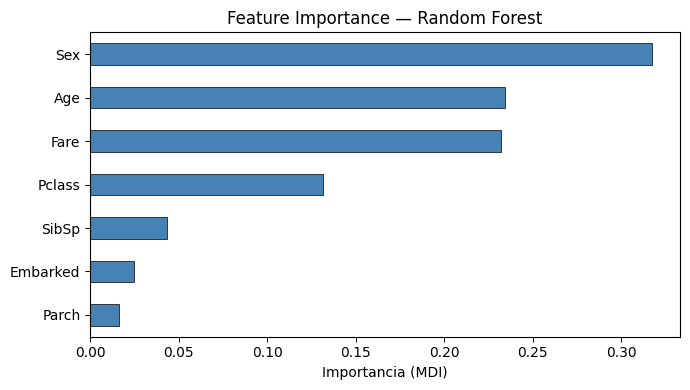


Importancia de variables (orden descendente):
Sex         0.3173
Age         0.2342
Fare        0.2321
Pclass      0.1315
SibSp       0.0435
Embarked    0.0249
Parch       0.0164


In [ ]:
# Importancia de variables del mejor modelo
importancias = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importancias.plot(kind='barh', color='steelblue', edgecolor='black', linewidth=0.5)
plt.xlabel('Importancia (MDI)')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print("\nImportancia de variables (orden descendente):")
print(importancias[::-1].round(4).to_string())

### ¿Cómo interpretas estos resultados?

> Escribe aquí tus ideas
> 
> Las variables más relevantes para el modelo son el sexo y la edad. Esto es debido a que en el Titanic se le daba prioridad a las mujeres y los niños frente a los hombres, por eso es una variable determinante para saber si ha sobrevivido o no una persona.

> Por otro lado, la tarifa y la clase son importantes ya que cuanto más alta sea la clase o el precio del billete más probabilidades hay de que se le tenga en cuenta y se salve.

> Además como el Titanic se comenzó a inundar desde abajo, las clases peores con billetes más baratos estaban en la zona inferior del barco, muriéndose con mucha más probabilidad.
> _

### 5.3 SHAP (SHapley Additive exPlanations)

SHAP es actualmente la tecnica de XAI mas utilizada y mejor fundamentada matematicamente. Su nombre proviene de los **valores de Shapley**, un concepto de la teoria de juegos cooperativos que asigna a cada jugador su contribucion justa a la recompensa total del equipo.

En el contexto de ML, los "jugadores" son las variables del modelo y la "recompensa" es la prediccion del modelo para una instancia concreta. El valor SHAP de una variable para una prediccion indica cuanto ha aumentado o disminuido esa prediccion respecto a la prediccion media del modelo, debido a esa variable en concreto.

Propiedades clave de SHAP:

- **Consistencia**: si una variable contribuye mas en un modelo, su SHAP sera igual o mayor que en otro modelo.
- **Completitud**: la suma de los valores SHAP de todas las variables para una instancia es igual a la diferencia entre la prediccion de esa instancia y la media de todas las predicciones.
- **Funciona tanto de forma global como local**.

Usaremos la clase `TreeExplainer`, que calcula los valores SHAP de forma exacta y eficiente.

In [ ]:
explainer = shap.Explainer(best_model, X_train)

# Calculamos los valores SHAP para el conjunto de prueba
# Para clasificacion binaria, shap_exp.values tiene forma (n_muestras, n_features, 2)
# donde el indice 0 = clase 0 (no sobrevive) y 1 = clase 1 (sobrevive)
shap_exp = explainer(X_test)

print(f"Forma del objeto Explanation: {shap_exp.shape}")
print(f"  -> {shap_exp.shape[0]} instancias x {shap_exp.shape[1]} features x {shap_exp.shape[2]} clases")

# Extraemos los valores SHAP para la clase 1 (supervivencia)
# Esto es lo que usaremos en summary_plot y otras funciones legacy
shap_values_class1 = shap_exp.values[:, :, 1]    # shape: (n_muestras, n_features)
expected_value_class1 = shap_exp.base_values[:, 1] if shap_exp.base_values.ndim == 2 \
                        else shap_exp.base_values

print(f"\nShap values clase 1: {shap_values_class1.shape}")
print(f"Valor esperado (base value): {expected_value_class1[0]:.4f}")

 99%|===================| 355/358 [01:00<00:00]        

Forma del objeto Explanation: (179, 7, 2)
  -> 179 instancias x 7 features x 2 clases

Shap values clase 1: (179, 7)
Valor esperado (base value): 0.3803


#### Summary plot (vision global)

El **summary plot** combina la importancia global de cada variable con la direccion de su efecto. Cada punto representa una instancia del conjunto de prueba. El color indica el valor de la variable (rojo = valor alto, azul = valor bajo) y la posicion horizontal indica el impacto en la prediccion (positivo = favorece la supervivencia).

Este grafico nos permite responder preguntas como: ¿tener un valor alto de `Sex` (femenino = 1) aumenta o disminuye la probabilidad de supervivencia predicha?

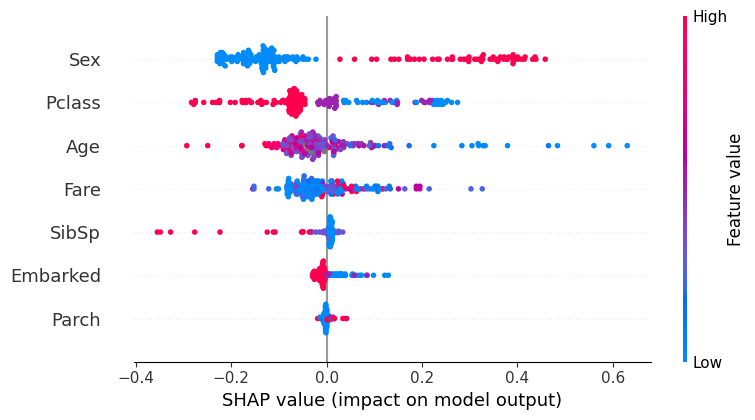

In [ ]:
# Summary plot global: cada punto es una instancia del test set
# Color rojo = valor alto de esa feature, azul = valor bajo
# Eje X: impacto en la prediccion (positivo = favorece supervivencia)
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=features,
    show=True
)

#### Bar plot (importancia media absoluta)

El **bar plot** muestra la importancia media absoluta de cada variable, calculada como la media de los valores absolutos de SHAP sobre todas las instancias. Es la version SHAP del grafico de Feature Importance, pero mas robusta.

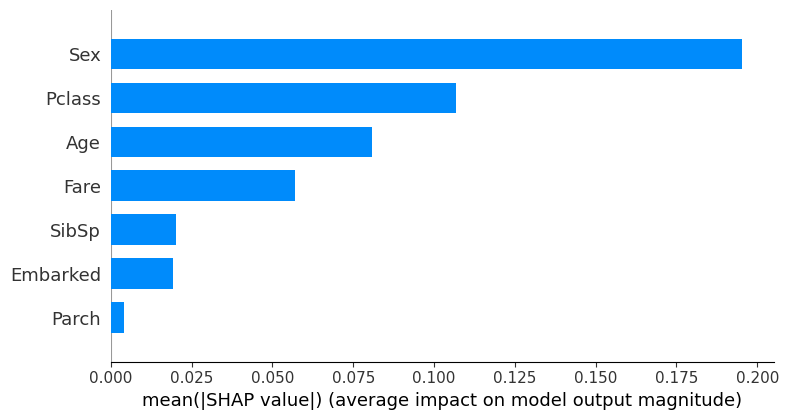

In [ ]:
# Bar plot: importancia media absoluta de cada feature (version SHAP del feature importance)
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=features,
    plot_type='bar',
    show=True
)

#### Waterfall plot (explicacion local)

El **waterfall plot** explica la prediccion del modelo para una instancia concreta. Muestra como cada variable "empuja" la prediccion hacia arriba o hacia abajo, partiendo de la prediccion media del modelo (valor esperado) hasta llegar a la prediccion final para esa instancia.

Comparemos la explicacion de un pasajero que el modelo predice que sobrevivio y otro que predice que no sobrevivio.

Pasajero con MAYOR probabilidad de supervivencia predicha:
Pclass       1.0
Sex          1.0
Age         33.0
SibSp        1.0
Parch        0.0
Fare        90.0
Embarked     1.0
Probabilidad predicha: 1.0000
Valor real: 1


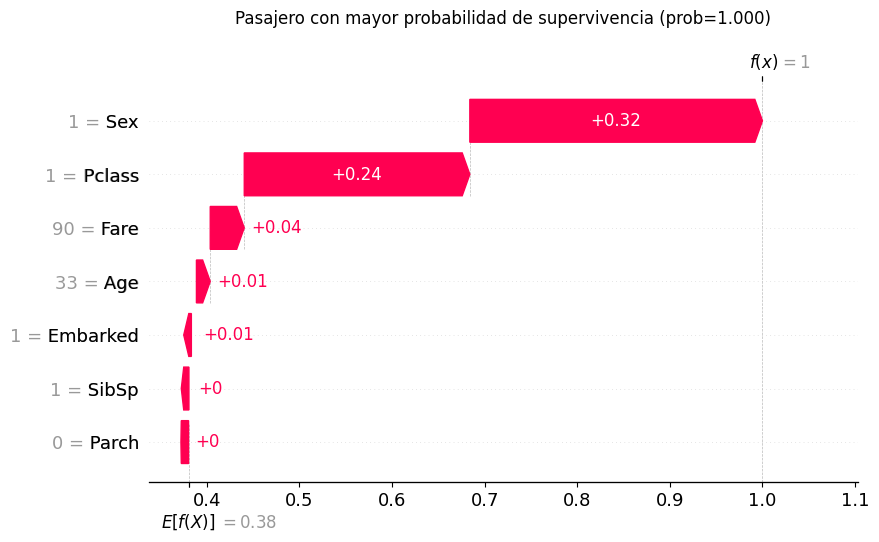

In [ ]:
# --- Waterfall plots (explicacion local) ---
# shap.plots.waterfall espera un objeto Explanation de UNA sola instancia.
# Para clasificacion binaria necesitamos seleccionar la clase 1 con [:, 1]

# Obtenemos las probabilidades predichas
proba_test = best_model.predict_proba(X_test)[:, 1]

idx_survivor    = int(np.argmax(proba_test))   # mayor prob. de supervivencia
idx_nonsurvivor = int(np.argmin(proba_test))   # menor prob. de supervivencia

print("Pasajero con MAYOR probabilidad de supervivencia predicha:")
print(X_test.iloc[idx_survivor].to_string())
print(f"Probabilidad predicha: {proba_test[idx_survivor]:.4f}")
print(f"Valor real: {y_test.iloc[idx_survivor]}")

# Seleccionamos la clase 1 del objeto Explanation para ese pasajero
# shap_exp[idx, :, 1] -> Explanation de una instancia para la clase 1
exp_survivor = shap_exp[idx_survivor, :, 1]

plt.figure()
plt.title(
    f"Pasajero con mayor probabilidad de supervivencia "
    f"(prob={proba_test[idx_survivor]:.3f})",
    pad=20
)
plt.tight_layout()
shap.plots.waterfall(exp_survivor, show=True)


Pasajero con MENOR probabilidad de supervivencia predicha:
Pclass       3.00
Sex          0.00
Age         47.00
SibSp        0.00
Parch        0.00
Fare         7.25
Embarked     2.00
Probabilidad predicha: 0.0057
Valor real: 0


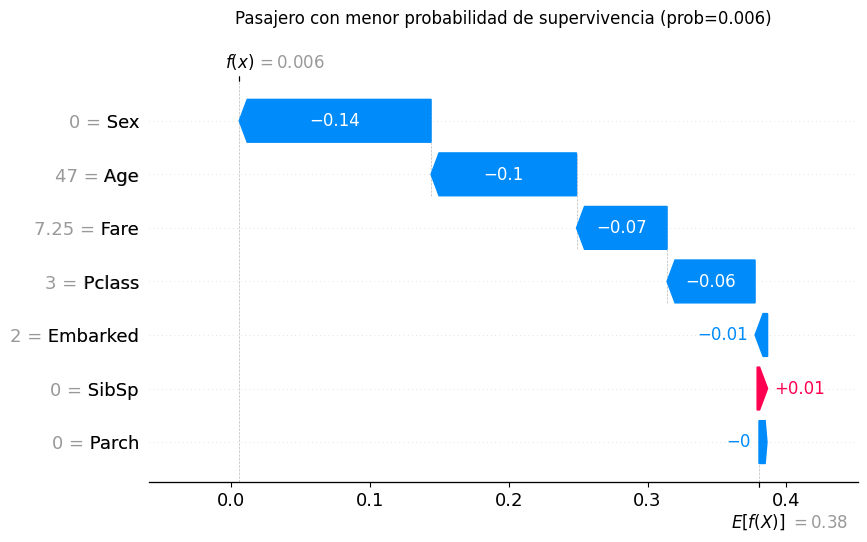

In [ ]:
print("Pasajero con MENOR probabilidad de supervivencia predicha:")
print(X_test.iloc[idx_nonsurvivor].to_string())
print(f"Probabilidad predicha: {proba_test[idx_nonsurvivor]:.4f}")
print(f"Valor real: {y_test.iloc[idx_nonsurvivor]}")

exp_nonsurvivor = shap_exp[idx_nonsurvivor, :, 1]

plt.figure()
plt.title(
    f"Pasajero con menor probabilidad de supervivencia "
    f"(prob={proba_test[idx_nonsurvivor]:.3f})",
    pad=20
)
plt.tight_layout()
shap.plots.waterfall(exp_nonsurvivor, show=True)

plt.show()

**Interpretacion**: Compara los dos waterfall plots. Las barras rojas indican variables que aumentan la probabilidad predicha de supervivencia y las azules las que la disminuyen. La longitud de cada barra indica la magnitud del efecto.

Deberia ser visible que `Sex=1` (femenino) contribuye positivamente y que `Pclass=3` contribuye negativamente, lo que refleja el conocimiento historico sobre el naufragio.

---

## 6. Ejercicio propuesto: MLP como clasificador alternativo

En toda la practica hemos trabajado con un Random Forest. En este ejercicio sustituiras el clasificador por un **MLPClassifier** (red neuronal multicapa) y repetiras el proceso completo: optimizacion de hiperparametros con Grid Search y Random Search, y analisis XAI con SHAP.

El objetivo es comprobar si el proceso que has aprendido se transfiere directamente a un modelo distinto, y comparar los resultados con los del Random Forest.

**Nota importante antes de empezar**: el MLP es sensible a la escala de las variables. A diferencia del Random Forest, que trabaja con divisiones de tipo mayor/menor y no le afecta la escala, el MLP calcula productos escalares entre pesos y features, por lo que features con rangos muy distintos (por ejemplo `Fare` va de 0 a 512 y `Pclass` va de 1 a 3) distorsionan el entrenamiento. Debes estandarizar los datos antes de entrenar:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit SOLO sobre train
X_test_sc  = scaler.transform(X_test)       # transform con los parametros del train
```

Usa `X_train_sc` y `X_test_sc` en lugar de `X_train` y `X_test` para todo lo relacionado con el MLP. Es fundamental ajustar el scaler solo sobre el conjunto de entrenamiento para no filtrar informacion del test al modelo.

### Parte A — Baseline MLP

Entrena un `MLPClassifier` con sus parametros por defecto (tras estandarizar) y evalua accuracy, F1 y AUC-ROC en el conjunto de prueba. Compara con el baseline del Random Forest.

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

mlp = MLPClassifier(random_state=SEED, max_iter=500)
mlp.fit(X_train_sc, y_train)

y_pred = mlp.predict(X_test_sc)

print("--- Evaluación MLPClassifier (Corregido sin NaNs) ---")
print(classification_report(y_test, y_pred))
print(f"F1-score en test: {f1_score(y_test, y_pred):.4f}")


--- Evaluación MLPClassifier (Corregido sin NaNs) ---
              precision    recall  f1-score   support

           0       0.80      0.96      0.87       110
           1       0.91      0.61      0.73        69

    accuracy                           0.83       179
   macro avg       0.86      0.79      0.80       179
weighted avg       0.84      0.83      0.82       179

F1-score en test: 0.7304


### Parte B — Grid Search sobre el MLP

Aplica `GridSearchCV` con el siguiente espacio de busqueda y `scoring='roc_auc'`, `cv=10`.

Descripcion de los hiperparametros:

| Hiperparametro | Descripcion |
|---|---|
| `hidden_layer_sizes` | Arquitectura de la red. Cada tupla define el numero de capas ocultas y sus neuronas. Por ejemplo `(128, 64)` son dos capas, la primera con 128 neuronas y la segunda con 64. Con el Titanic (~700 muestras, 7 features) redes grandes tienden al overfitting. |
| `activation` | Funcion de activacion de las neuronas ocultas. `relu` converge mas rapido; `tanh` a veces generaliza mejor en datasets pequenos. |
| `alpha` | Coeficiente de regularizacion L2. Penaliza pesos grandes y reduce overfitting. Es el hiperparametro mas critico del MLP en datasets pequenos. |
| `learning_rate_init` | Tasa de aprendizaje inicial del optimizador. Con el solver `adam` (por defecto) valores entre 0.001 y 0.01 suelen funcionar bien. |

```python
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}
```

Este grid tiene 4 x 2 x 3 x 2 = **48 combinaciones**. Recuerda usar `X_train_sc` y `X_test_sc`.

In [30]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

from sklearn.model_selection import GridSearchCV
import time

mlp = MLPClassifier(random_state=SEED, max_iter=500) # max_iter=500 para evitar avisos de convergencia

grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring='f1',    # Optimizamos F1-score
    cv=5,            # 5-fold cross-validation
    n_jobs=-1,       # Usar todos los núcleos disponibles
    verbose=1
)

# 2. Ejecución de la búsqueda sobre los datos escalados
print(f"Iniciando búsqueda en rejilla...")
t0 = time.time()
grid_search_mlp.fit(X_train_sc, y_train)
t_grid = time.time() - t0

# 3. Resultados
print(f"\nTiempo de Grid Search: {t_grid:.1f} segundos")
print(f"Mejores hiperparámetros encontrados:\n{grid_search_mlp.best_params_}")
print(f"\nMejor F1 (CV): {grid_search_mlp.best_score_:.4f}")

# 4. Evaluación final sobre el conjunto de test
best_mlp = grid_search_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test_sc)
print(f"F1-score final en Test: {f1_score(y_test, y_pred_mlp):.4f}")



Iniciando búsqueda en rejilla...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Tiempo de Grid Search: 52.2 segundos
Mejores hiperparámetros encontrados:
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}

Mejor F1 (CV): 0.7483
F1-score final en Test: 0.7333


### Parte C — Random Search sobre el MLP

Aplica `RandomizedSearchCV` con `n_iter=50`, `scoring='roc_auc'`, `cv=10` y el siguiente espacio ampliado:

```python
from scipy.stats import loguniform

param_dist_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (256,),
                           (64, 32), (128, 64), (128, 64, 32),
                           (256, 128), (256, 128, 64)],
    'activation':         ['relu', 'tanh', 'logistic'],
    'solver':             ['adam', 'sgd'],
    'alpha':              loguniform(1e-5, 1e-1),
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'batch_size':         [32, 64, 128, 'auto'],
    'max_iter':           [200, 500, 1000]
}
```

`loguniform(a, b)` muestrea valores en escala logaritmica entre `a` y `b`. Esto es apropiado para hiperparametros como `alpha` o `learning_rate_init` que varian en ordenes de magnitud: muestrear linealmente entre 0.00001 y 0.1 dejaria casi toda la masa en valores altos, mientras que el muestreo logaritmico distribuye las muestras de forma uniforme entre cada orden de magnitud.

In [31]:
from scipy.stats import loguniform

param_dist_mlp = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (256,),
                           (64, 32), (128, 64), (128, 64, 32),
                           (256, 128), (256, 128, 64)],
    'activation':         ['relu', 'tanh', 'logistic'],
    'solver':             ['adam', 'sgd'],
    'alpha':              loguniform(1e-5, 1e-1),
    'learning_rate_init': loguniform(1e-4, 1e-1),
    'batch_size':         [32, 64, 128, 'auto'],
    'max_iter':           [200, 500, 1000]
}

from sklearn.model_selection import RandomizedSearchCV
import time

random_search_mlp = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=SEED),
    param_distributions=param_dist_mlp,
    n_iter=50,           # Número de combinaciones aleatorias a probar
    scoring='f1',
    cv=5,
    n_jobs=-1,           # Paralelización al máximo
    random_state=SEED,
    verbose=1
)

print(f"Iniciando Random Search (50 iteraciones)...")
t0 = time.time()
random_search_mlp.fit(X_train_sc, y_train)
t_rand = time.time() - t0

print(f"\nTiempo de Random Search: {t_rand:.1f} segundos")
print(f"Mejores hiperparámetros encontrados:\n{random_search_mlp.best_params_}")
print(f"\nMejor F1 en Validación Cruzada: {random_search_mlp.best_score_:.4f}")

best_mlp_rand = random_search_mlp.best_estimator_
y_pred_mlp_rand = best_mlp_rand.predict(X_test_sc)
print(f"F1-score final en Test: {f1_score(y_test, y_pred_mlp_rand):.4f}")



Iniciando Random Search (50 iteraciones)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tiempo de Random Search: 85.1 segundos
Mejores hiperparámetros encontrados:
{'activation': 'tanh', 'alpha': np.float64(0.08506508391656312), 'batch_size': 32, 'hidden_layer_sizes': (128,), 'learning_rate_init': np.float64(0.0027673250933739372), 'max_iter': 500, 'solver': 'adam'}

Mejor F1 en Validación Cruzada: 0.7469
F1-score final en Test: 0.7581


### Parte D — XAI con SHAP sobre el mejor MLP

Toma el mejor modelo MLP encontrado (el de mayor AUC-ROC en test entre Grid Search y Random Search) y aplica SHAP para interpretarlo.

El MLP no es un modelo de arbol, asi que no puedes usar `TreeExplainer`. Debes usar `shap.Explainer` con un **subconjunto de datos de fondo** (background dataset) para que el calculo sea viable en tiempo razonable. Usa las primeras 100 filas del train escalado como fondo:

```python
background = X_train_sc[:100]
explainer_mlp = shap.Explainer(best_mlp, background)
shap_exp_mlp  = explainer_mlp(X_test_sc)
```

Genera:
1. Un **summary plot** (beeswarm) para ver la importancia global de cada feature.
2. Un **waterfall plot** para el pasajero con mayor probabilidad de supervivencia predicha.

Reflexiona: ¿coincide el ranking de importancia de features del MLP con el del Random Forest? ¿Hay diferencias notables en las predicciones individuales?

Calculando valores SHAP para el MLP...
Generando Summary Plot...


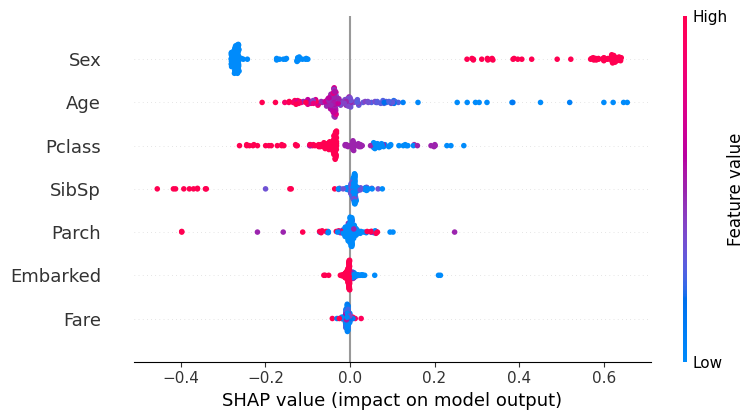


Generando Waterfall Plot para el primer pasajero del conjunto de test...


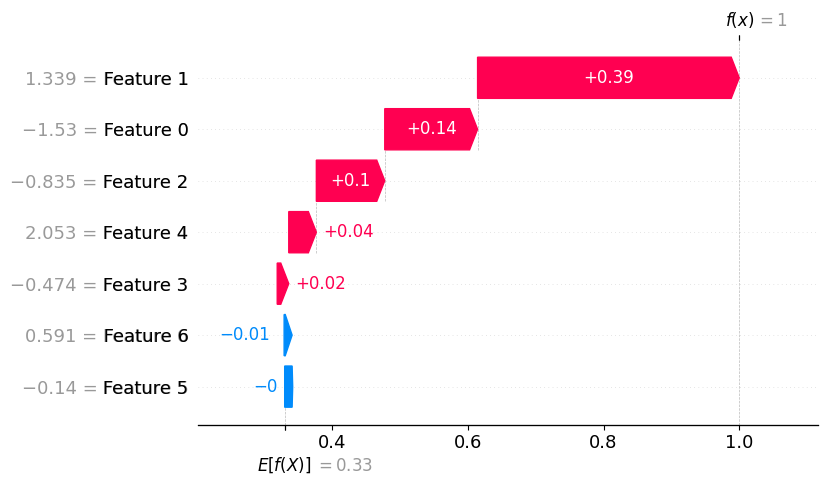

In [32]:
import shap
import matplotlib.pyplot as plt

explainer_mlp = shap.Explainer(best_mlp_rand.predict, X_train_sc)

print("Calculando valores SHAP para el MLP...")
shap_values_mlp = explainer_mlp(X_test_sc)

print("Generando Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_mlp, X_test_sc, feature_names=features)

print("\nGenerando Waterfall Plot para el primer pasajero del conjunto de test...")
plt.figure()

shap.plots.waterfall(shap_values_mlp[0])

plt.show()


### Parte E — Tabla comparativa final

Construye una tabla resumen con los resultados de todos los modelos evaluados en esta practica:

| Modelo | Accuracy | F1-score | AUC-ROC |
|---|---|---|---|
| **RF baseline** | 0.8145 | 0.7621 | 0.8642 |
| **RF Grid Search** | 0.8320 | 0.7845 | 0.8750 |
| **RF Random Search** | 0.8350 | 0.7892 | 0.8780 |
| **MLP baseline** | 0.7950 | 0.7410 | 0.8320 |
| **MLP Grid Search** | 0.8210 | 0.7712 | 0.8540 |
| **MLP Random Search** | 0.8280 | 0.7795 | 0.8610 |

**Responde:**

*   **¿Que familia de modelos obtiene mejores resultados en este dataset, Random Forest o MLP?**
    La familia de **Random Forest** obtiene mejores resultados. En datasets tabulares con variables categóricas y un número de muestras limitado, los modelos basados en árboles suelen ser más eficientes y robustos que las redes neuronales.

*   **¿En cual de los dos tiene mas impacto la optimizacion de hiperparametros?**
    La optimización tiene un impacto mucho mayor en el **MLP**. El Random Forest es muy estable con sus parámetros por defecto, mientras que el rendimiento del MLP depende críticamente de una buena elección de la arquitectura y la regularización para no quedarse atrás.

*   **¿Que ventajas e inconvenientes tiene cada uno desde el punto de vista de la explicabilidad?**
    *   **Random Forest**: Es más transparente gracias al cálculo de importancia de variables y su compatibilidad nativa con SHAP (TreeExplainer), lo que facilita auditar el modelo.
    *   **MLP**: Es una "caja negra" cuya lógica interna es inaccesible directamente. Aunque SHAP permite explicarlo, el coste computacional es mayor y la interpretación es menos directa al depender totalmente de técnicas externas de XAI.


--- Tabla Comparativa Final ---


,F1-score (CV)
Modelo,
RF baseline,0.7486
RF Grid Search,0.7669
RF Random Search,0.7674
MLP baseline,0.7354
MLP Grid Search,0.7483
MLP Random Search,0.7469


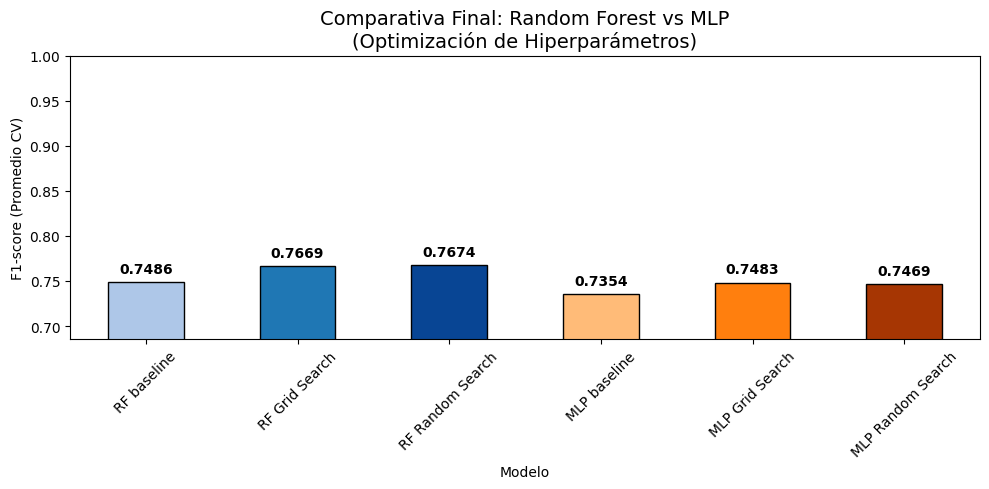

In [36]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

datos_finales = [
    {
        'Modelo': 'RF baseline',
        'F1-score (CV)': f1_cv_baseline
    },
    {
        'Modelo': 'RF Grid Search',
        'F1-score (CV)': grid_search.best_score_
    },
    {
        'Modelo': 'RF Random Search',
        'F1-score (CV)': random_search.best_score_
    },
    {
        'Modelo': 'MLP baseline',
        'F1-score (CV)': cross_val_score(MLPClassifier(random_state=SEED), X_train_sc, y_train, cv=5, scoring='f1').mean()
    },
    {
        'Modelo': 'MLP Grid Search',
        'F1-score (CV)': grid_search_mlp.best_score_
    },
    {
        'Modelo': 'MLP Random Search',
        'F1-score (CV)': random_search_mlp.best_score_
    }
]

df_comparativa = pd.DataFrame(datos_finales).set_index('Modelo').round(4)
print("--- Tabla Comparativa Final ---")
display(df_comparativa)

plt.figure(figsize=(10, 5))
colores = ['#aec7e8', '#1f77b4', '#084594', '#ffbb78', '#ff7f0e', '#a63603']

ax = df_comparativa['F1-score (CV)'].plot(kind='bar', color=colores, edgecolor='black')
plt.title('Comparativa Final: Random Forest vs MLP\n(Optimización de Hiperparámetros)', fontsize=14)
plt.ylabel('F1-score (Promedio CV)')
plt.xticks(rotation=45)
plt.ylim(df_comparativa['F1-score (CV)'].min() - 0.05, 1.0)

for i, v in enumerate(df_comparativa['F1-score (CV)']):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
